# 数据并行 — 从零开始

> **难度：** 入门 → 中级 | **预计时间：** ~45 分钟

本笔记本讲解**数据并行（Data Parallelism, DP）**——分布式深度学习中最基础、最常用的技术。

**无需任何分布式训练背景知识。** 我们从零开始讲起。

## 1. 为什么需要多块 GPU？

想象你是一位老师，要批改 1,000 份试卷——一个人做实在太慢了。
但如果 4 位老师**各批改 250 份**，最后**汇总结果**，速度就能快约 4 倍。

**数据并行的原理完全一样：**
- 每块 GPU 就像一位老师
- 试卷就是训练数据
- "汇总结果" = 同步每块 GPU 学到的东西（梯度）

我们先画一张图，再详细解释。

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from mp_tutorial.distributed import check_gpu_env, simulate_allreduce
from mp_tutorial.viz import draw_comm_pattern
from mp_tutorial.formatting import info_box, gpu_required_banner, comparison_table, code_reference
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

### 核心概念（一图读懂）

下面这张图包含了数据并行的**全部核心思想**。先看图，后面的内容都是围绕它展开。

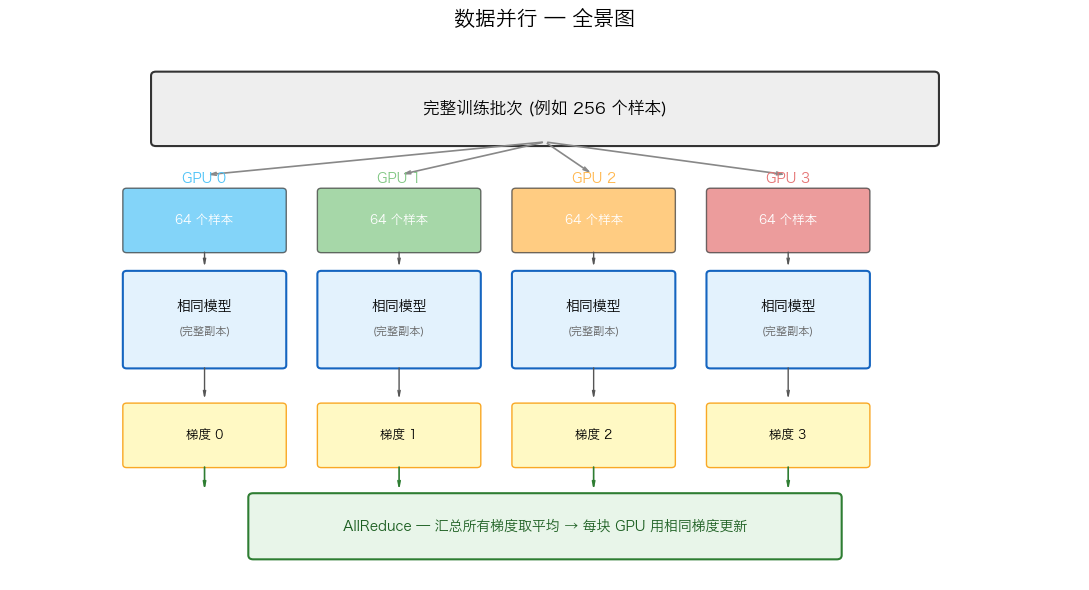

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6.5)
ax.axis("off")
ax.set_title("数据并行 — 全景图", fontsize=15, fontweight="bold", pad=12)

gpu_colors = ["#4FC3F7", "#81C784", "#FFB74D", "#E57373"]

# 完整批次
ax.add_patch(patches.FancyBboxPatch((1.5, 5.3), 8, 0.8, boxstyle="round,pad=0.05",
    facecolor="#eeeeee", edgecolor="#333", lw=1.5))
ax.text(5.5, 5.7, "完整训练批次 (例如 256 个样本)", ha="center", va="center",
    fontsize=12, fontweight="bold")

# 分割箭头
for i in range(4):
    x = 2.0 + i * 2.0
    ax.annotate("", xy=(x, 4.9), xytext=(5.5, 5.3),
        arrowprops=dict(arrowstyle="->,head_width=0.1", color="#888", lw=1.2))

# 4 个 GPU 列
for i in range(4):
    x = 1.2 + i * 2.0
    # 微批次
    ax.add_patch(patches.FancyBboxPatch((x, 4.0), 1.6, 0.7, boxstyle="round,pad=0.04",
        facecolor=gpu_colors[i], edgecolor="#333", lw=1, alpha=0.7))
    ax.text(x + 0.8, 4.35, f"64 个样本", ha="center", va="center", fontsize=9, color="white",
        fontweight="bold")

    # 模型副本
    ax.add_patch(patches.FancyBboxPatch((x, 2.6), 1.6, 1.1, boxstyle="round,pad=0.04",
        facecolor="#e3f2fd", edgecolor="#1565c0", lw=1.5))
    ax.text(x + 0.8, 3.3, "相同模型", ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(x + 0.8, 3.0, "(完整副本)", ha="center", va="center", fontsize=8, color="#666")

    # 箭头
    ax.annotate("", xy=(x + 0.8, 3.75), xytext=(x + 0.8, 4.0),
        arrowprops=dict(arrowstyle="->,head_width=0.08", color="#555", lw=1))

    # 梯度
    ax.add_patch(patches.FancyBboxPatch((x, 1.4), 1.6, 0.7, boxstyle="round,pad=0.04",
        facecolor="#fff9c4", edgecolor="#f9a825", lw=1))
    ax.text(x + 0.8, 1.75, f"梯度 {i}", ha="center", va="center", fontsize=9, fontweight="bold")

    ax.annotate("", xy=(x + 0.8, 2.15), xytext=(x + 0.8, 2.6),
        arrowprops=dict(arrowstyle="->,head_width=0.08", color="#555", lw=1))

    ax.text(x + 0.8, 4.85, f"GPU {i}", ha="center", va="center", fontsize=10, fontweight="bold",
        color=gpu_colors[i])

# 同步
ax.add_patch(patches.FancyBboxPatch((2.5, 0.3), 6, 0.7, boxstyle="round,pad=0.05",
    facecolor="#e8f5e9", edgecolor="#2e7d32", lw=1.5))
ax.text(5.5, 0.65, "AllReduce — 汇总所有梯度取平均 → 每块 GPU 用相同梯度更新",
    ha="center", va="center", fontsize=10, fontweight="bold", color="#1b5e20")

for i in range(4):
    x = 2.0 + i * 2.0
    ax.annotate("", xy=(x, 1.05), xytext=(x, 1.4),
        arrowprops=dict(arrowstyle="->,head_width=0.08", color="#2e7d32", lw=1.2))

plt.tight_layout()
plt.show()

### 关键术语（零基础必读）

在深入之前，确保你理解这些基础概念：

In [3]:
info_box(
    "<b>张量（Tensor）</b> — 多维数组。一维张量是向量，二维张量是矩阵。模型权重和数据都是张量。<br><br>"
    "<b>前向传播（Forward Pass）</b> — 将输入数据送入模型，得到预测结果。<br><br>"
    "<b>损失（Loss）</b> — 一个标量，衡量预测结果有多“错”。越小越好。<br><br>"
    "<b>反向传播（Backward Pass / Backpropagation）</b> — 计算每个权重对损失的贡献程度。"
    "结果是每个权重对应的<i>梯度</i>。<br><br>"
    "<b>梯度（Gradient）</b> — 与权重形状相同的张量，指示如何调整权重才能减小损失。<br><br>"
    "<b>优化器步骤（Optimizer Step）</b> — 用梯度实际更新权重"
    "（例如 <code>weight -= learning_rate × gradient</code>）。",
    title="术语表 — 深度学习核心概念"
)

## 2. 单 GPU 训练（基准）

在讲并行之前，先看看**单卡**上的训练流程。
数据并行只不过是让多块 GPU 同时执行这个流程。

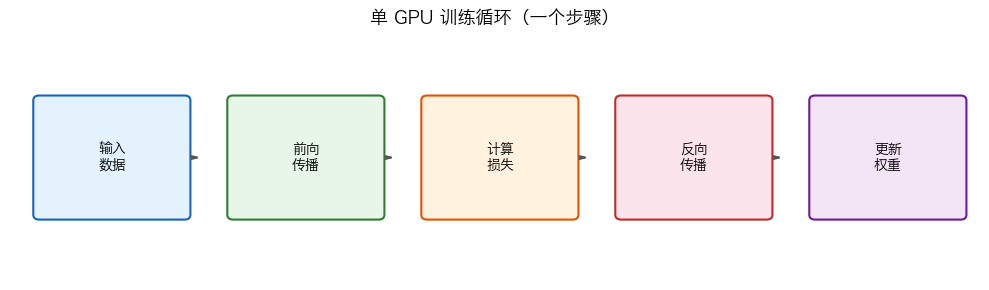

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")
ax.set_title("单 GPU 训练循环（一个步骤）", fontsize=13, fontweight="bold", pad=8)

steps = [
    (0.3, "输入\n数据", "#e3f2fd", "#1565c0"),
    (2.3, "前向\n传播", "#e8f5e9", "#2e7d32"),
    (4.3, "计算\n损失", "#fff3e0", "#e65100"),
    (6.3, "反向\n传播", "#fce4ec", "#c62828"),
    (8.3, "更新\n权重", "#f3e5f5", "#6a1b9a"),
]
for i, (x, label, fc, ec) in enumerate(steps):
    ax.add_patch(patches.FancyBboxPatch((x, 0.8), 1.5, 1.4, boxstyle="round,pad=0.06",
        facecolor=fc, edgecolor=ec, lw=1.5))
    ax.text(x + 0.75, 1.5, label, ha="center", va="center", fontsize=10, fontweight="bold")
    if i < len(steps) - 1:
        ax.annotate("", xy=(x + 1.7, 1.5), xytext=(x + 1.55, 1.5),
            arrowprops=dict(arrowstyle="->,head_width=0.1", color="#555", lw=1.5))

plt.tight_layout()
plt.show()

### 用真实数字感受一下

让我们在一个微型模型上跑一步训练，看看每个数字的变化：

In [5]:
torch.manual_seed(42)

# 一个微型模型：单层线性层（2 个输入 → 3 个输出）
model = nn.Linear(2, 3, bias=False)
print("模型权重（训练前）：")
print(model.weight.data)
print(f"形状：{model.weight.shape}  (3 个输出 × 2 个输入)\n")

# 一个小批次：4 个样本，每个有 2 个特征
X = torch.tensor([[1.0, 0.0],
                   [0.0, 1.0],
                   [1.0, 1.0],
                   [0.5, 0.5]])
y_true = torch.tensor([[1.0, 0.0, 0.0],
                        [0.0, 1.0, 0.0],
                        [1.0, 1.0, 0.0],
                        [0.5, 0.5, 0.0]])

# 前向传播
y_pred = model(X)
print("预测结果（前向传播）：")
print(y_pred.data.round(decimals=3))

# 计算损失
loss = ((y_pred - y_true) ** 2).mean()
print(f"\n损失值：{loss.item():.4f}")

# 反向传播
loss.backward()
print(f"\n梯度（与权重形状相同）：")
print(model.weight.grad.round(decimals=3))

# 更新权重
lr = 0.1
with torch.no_grad():
    model.weight -= lr * model.weight.grad
print(f"\n模型权重（更新后）：")
print(model.weight.data.round(decimals=3))

模型权重（训练前）：
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427]])
形状：torch.Size([3, 2])  (3 个输出 × 2 个输入)

预测结果（前向传播）：
tensor([[ 0.5410, -0.1660, -0.1550],
        [ 0.5870,  0.6500,  0.1430],
        [ 1.1280,  0.4840, -0.0120],
        [ 0.5640,  0.2420, -0.0060]])

损失值：0.0920

梯度（与权重形状相同）：
tensor([[-0.0500,  0.1240],
        [-0.1350, -0.1660],
        [-0.0280,  0.0210]])

模型权重（更新后）：
tensor([[ 0.5460,  0.5740],
        [-0.1520,  0.6660],
        [-0.1520,  0.1410]])


## 3. 最朴素的数据并行

现在假设我们有 **4 块 GPU**。不再让一块 GPU 处理全部 4 个样本，
而是每块 GPU 只处理 1 个。每块 GPU：
1. 拥有模型的**完整副本**（初始权重相同）
2. 处理**自己那份数据**
3. 计算**自己的梯度**

然后它们**同步**，让每块 GPU 都得到相同的平均梯度。

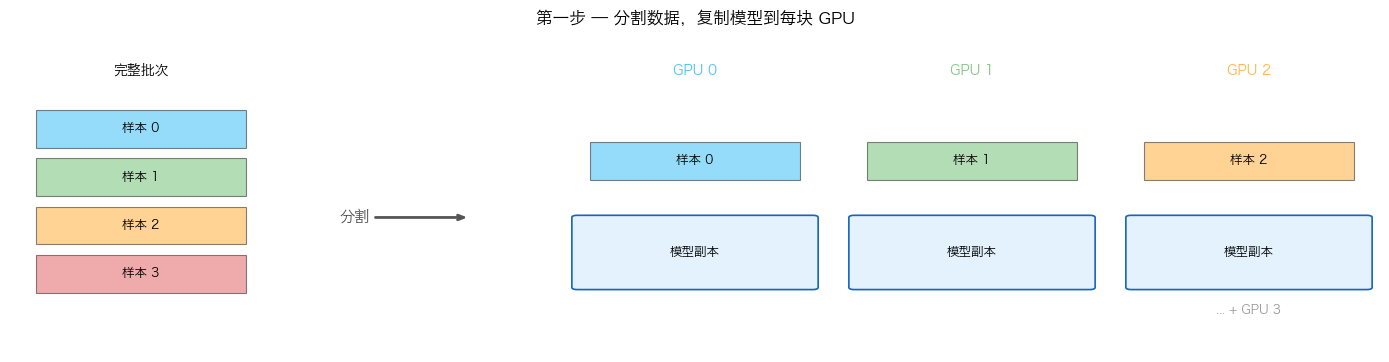

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
gpu_colors = ["#4FC3F7", "#81C784", "#FFB74D", "#E57373"]

# 左侧完整批次
ax = axes[0]
ax.set_xlim(0, 2); ax.set_ylim(0, 5); ax.axis("off")
ax.set_title("完整批次", fontsize=10, fontweight="bold")
for r in range(4):
    color = gpu_colors[r]
    ax.add_patch(patches.Rectangle((0.2, 3.8 - r * 0.9), 1.6, 0.7,
        facecolor=color, edgecolor="#333", lw=0.8, alpha=0.6))
    ax.text(1.0, 4.15 - r * 0.9, f"样本 {r}", ha="center", va="center", fontsize=9)

# 箭头
ax = axes[1]
ax.set_xlim(0, 1); ax.set_ylim(0, 5); ax.axis("off")
ax.annotate("分割", xy=(0.7, 2.5), xytext=(0.2, 2.5),
    arrowprops=dict(arrowstyle="->,head_width=0.15", color="#555", lw=2),
    fontsize=11, va="center", color="#555")

# 每块 GPU 得到一个样本
for g in range(3):
    ax = axes[g + 2]
    ax.set_xlim(0, 2); ax.set_ylim(0, 5); ax.axis("off")
    ax.set_title(f"GPU {g}", fontsize=10, fontweight="bold", color=gpu_colors[g])
    ax.add_patch(patches.Rectangle((0.2, 3.2), 1.6, 0.7,
        facecolor=gpu_colors[g], edgecolor="#333", lw=0.8, alpha=0.6))
    ax.text(1.0, 3.55, f"样本 {g}", ha="center", va="center", fontsize=9)
    ax.add_patch(patches.FancyBboxPatch((0.1, 1.2), 1.8, 1.3, boxstyle="round,pad=0.04",
        facecolor="#e3f2fd", edgecolor="#1565c0", lw=1.2))
    ax.text(1.0, 1.85, "模型副本", ha="center", va="center", fontsize=9, fontweight="bold")
    if g == 2:
        ax.text(1.0, 0.7, "... + GPU 3", ha="center", fontsize=9, color="#999")

plt.suptitle("第一步 — 分割数据，复制模型到每块 GPU", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 用真实张量模拟数据并行

我们用 `simulate_allreduce` 在 CPU 上模拟 GPU 间的通信。

In [7]:
torch.manual_seed(42)
num_gpus = 4

# 相同的初始权重（复制到每块"GPU"）
W_init = torch.randn(3, 2)
print("初始权重（所有 GPU 相同）：")
print(W_init.round(decimals=3))
print()

# 将 4 个样本分配给 4 块 GPU
all_X = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [0.5, 0.5]])
all_y = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [1.0, 1.0, 0.0], [0.5, 0.5, 0.0]])

local_grads = []
for i in range(num_gpus):
    W = W_init.clone().requires_grad_(True)
    x_i = all_X[i:i+1]
    y_i = all_y[i:i+1]
    pred = x_i @ W.T
    loss = ((pred - y_i) ** 2).mean()
    loss.backward()
    local_grads.append(W.grad.clone())
    print(f"GPU {i}: 样本={all_X[i].tolist()}, 损失={loss.item():.4f}, 梯度范数={W.grad.norm():.4f}")

print("\n--- 各 GPU 本地梯度（数据不同，所以梯度也不同）---")
for i, g in enumerate(local_grads):
    print(f"  GPU {i}: {g[0].tolist()}")

初始权重（所有 GPU 相同）：
tensor([[ 0.3370,  0.1290],
        [ 0.2340,  0.2300],
        [-1.1230, -0.1860]])

GPU 0: 样本=[1.0, 0.0], 损失=0.5853, 梯度范数=0.8834
GPU 1: 样本=[0.0, 1.0], 损失=0.2146, 梯度范数=0.5349
GPU 2: 样本=[1.0, 1.0], 损失=0.7620, 梯度范数=1.4255
GPU 3: 样本=[0.5, 0.5], 损失=0.1905, 梯度范数=0.3564

--- 各 GPU 本地梯度（数据不同，所以梯度也不同）---
  GPU 0: [-0.4422064423561096, 0.0]
  GPU 1: [0.0, 0.08587294071912766]
  GPU 2: [-0.35633349418640137, -0.35633349418640137]
  GPU 3: [-0.08908337354660034, -0.08908337354660034]


### 第二步 — 同步梯度（AllReduce）

关键步骤：**AllReduce** 将所有 GPU 的梯度求和，使每块 GPU 都得到相同的总和。
然后除以 N 得到平均值。

> **AllReduce** 是一种集体通信操作——每个参与者既*发送*自己的数据，又*接收*汇总结果。
> 就像群聊中每个人分享自己的答案，最后每个人都能看到总和。

In [8]:
# AllReduce：每块 GPU 得到所有梯度的总和
synced = simulate_allreduce(local_grads)
avg_grads = [g / num_gpus for g in synced]

print("AllReduce + 取平均后：")
for i in range(num_gpus):
    print(f"  GPU {i}: {avg_grads[i][0].round(decimals=4).tolist()}")

print(f"\n全部相同？ {all(torch.allclose(avg_grads[0], avg_grads[i]) for i in range(1, num_gpus))}")

# 与单卡处理全部数据的结果对比
W_full = W_init.clone().requires_grad_(True)
pred_full = all_X @ W_full.T
loss_full = ((pred_full - all_y) ** 2).mean()
loss_full.backward()
print(f"\n单卡梯度（全部数据）：  {W_full.grad[0].round(decimals=4).tolist()}")
print(f"DP 平均梯度：             {avg_grads[0][0].round(decimals=4).tolist()}")
print(f"完全一致：{torch.allclose(avg_grads[0], W_full.grad)}")

AllReduce + 取平均后：
  GPU 0: [-0.22190000116825104, -0.08990000188350677]
  GPU 1: [-0.22190000116825104, -0.08990000188350677]
  GPU 2: [-0.22190000116825104, -0.08990000188350677]
  GPU 3: [-0.22190000116825104, -0.08990000188350677]

全部相同？ True

单卡梯度（全部数据）：  [-0.22190000116825104, -0.08990000188350677]
DP 平均梯度：             [-0.22190000116825104, -0.08990000188350677]
完全一致：True


In [9]:
info_box(
    "4 块 GPU 各处理 ¼ 数据后取平均梯度，与 1 块 GPU 处理全部数据的梯度<b>数学上完全一致</b>。"
    "数据并行给出的结果完全相同——只是更快！",
    title="核心发现"
)

### 可视化 AllReduce

GPU 之间的通信方式。在**环形（Ring）**拓扑中，数据沿环流动，没有单点瓶颈：

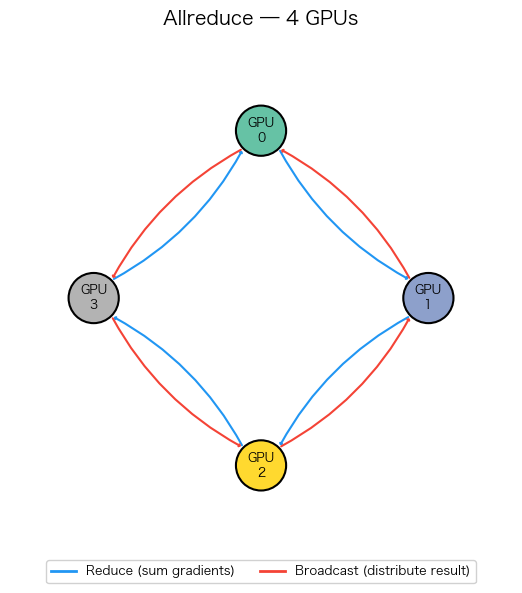

In [10]:
fig, ax = draw_comm_pattern("allreduce", num_gpus=4)
plt.show()

## 4. DistributedDataParallel（DDP）— 更高效的版本

朴素 DP 能用，但 PyTorch 的 `DistributedDataParallel` 通过两个技巧让它**更快**：

### 技巧一：梯度分桶（Gradient Bucketing）

DDP 不等所有梯度算完才开始同步，而是将梯度分成**桶**（约 25 MB 一个），
每个桶就绪后立即开始同步。

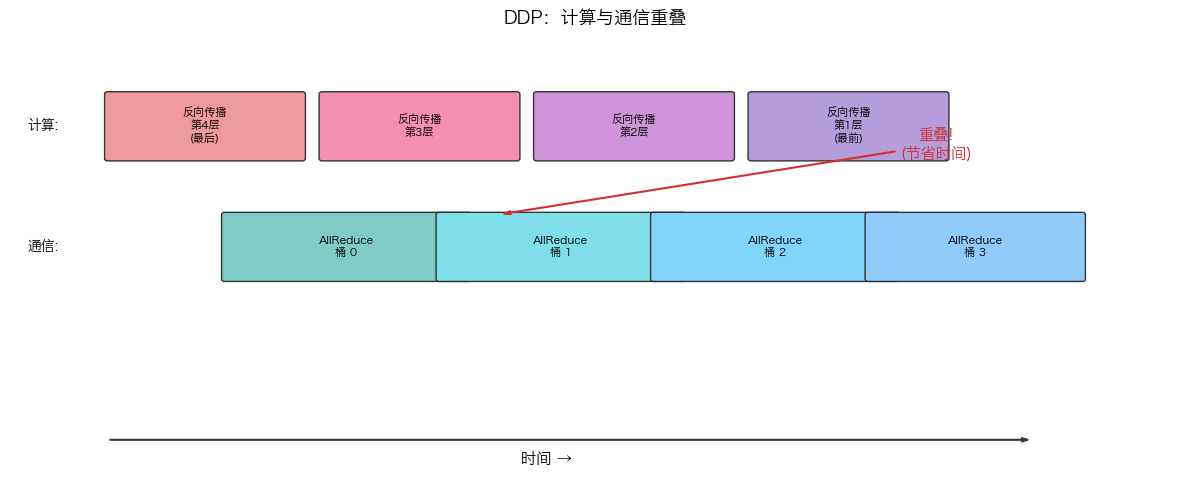

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("DDP：计算与通信重叠", fontsize=13, fontweight="bold", pad=10)

y_comp = 4.0; y_comm = 2.5
bar_h = 0.8

# 反向计算（从后往前）
layers = ["第4层\n(最后)", "第3层", "第2层", "第1层\n(最前)"]
layer_colors = ["#ef9a9a", "#f48fb1", "#ce93d8", "#b39ddb"]
for i, (label, color) in enumerate(zip(layers, layer_colors)):
    x = 1 + i * 2.2
    ax.add_patch(patches.FancyBboxPatch((x, y_comp), 2.0, bar_h, boxstyle="round,pad=0.03",
        facecolor=color, edgecolor="#333", lw=1))
    ax.text(x + 1.0, y_comp + bar_h/2, f"反向传播\n{label}", ha="center", va="center", fontsize=8, fontweight="bold")

# 通信
comm_colors = ["#80cbc4", "#80deea", "#81d4fa", "#90caf9"]
for i in range(4):
    x = 2.2 + i * 2.2
    w = 2.5
    if x + w > 11: w = 11 - x
    ax.add_patch(patches.FancyBboxPatch((x, y_comm), w, bar_h, boxstyle="round,pad=0.03",
        facecolor=comm_colors[i], edgecolor="#333", lw=1))
    ax.text(x + w/2, y_comm + bar_h/2, f"AllReduce\n桶 {i}", ha="center", va="center",
        fontsize=8, fontweight="bold")

ax.text(0.5, y_comp + bar_h/2, "计算:", ha="right", va="center", fontsize=10, fontweight="bold")
ax.text(0.5, y_comm + bar_h/2, "通信:", ha="right", va="center", fontsize=10, fontweight="bold")

ax.annotate("重叠!\n(节省时间)", xy=(5, 3.3), xytext=(9.5, 4.0),
    arrowprops=dict(arrowstyle="->,head_width=0.1", color="#d32f2f", lw=1.5),
    fontsize=11, fontweight="bold", color="#d32f2f", ha="center")

ax.annotate("", xy=(10.5, 0.5), xytext=(1, 0.5),
    arrowprops=dict(arrowstyle="->,head_width=0.12", color="#333", lw=1.5))
ax.text(5.5, 0.2, "时间 →", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
info_box(
    "<b>梯度分桶</b> — DDP 不是逐个梯度同步（消息太多太碎），也不是全部算完再同步（等太久）。"
    "而是把梯度分成约 25 MB 的桶，每个桶就绪后立即开始同步。这让通信和反向传播<i>重叠</i>，"
    "隐藏了大部分同步开销。",
    title="为什么分桶很重要"
)

## 5. 内存问题 — 为什么需要 ZeRO

标准 DP 将**所有东西**都复制到每块 GPU。让我们看看这浪费了多少显存：

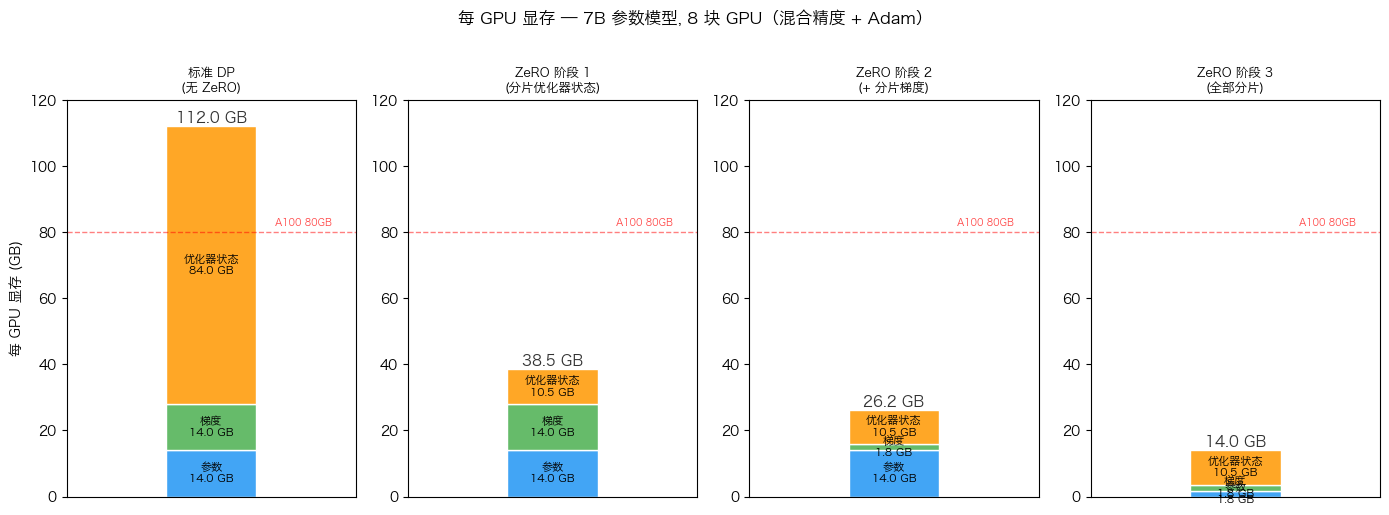

ZeRO 阶段,参数 (GB),梯度 (GB),优化器 (GB),总计 (GB),能放入 A100 80GB？
无 (DDP),14.0,14.0,84.0,112.0,否
阶段 1,14.0,14.0,10.5,38.5,是
阶段 2,14.0,1.8,10.5,26.2,是
阶段 3,1.8,1.8,10.5,14.0,是


In [13]:
# 混合精度 + Adam 优化器下的显存分析
def memory_breakdown(num_params_B, num_gpus, zero_stage=0):
    """计算每块 GPU 的显存占用（GB），混合精度 + Adam。"""
    P = num_params_B * 1e9
    if zero_stage == 0:
        params_gb = P * 2 / 1e9
        grads_gb = P * 2 / 1e9
        opt_gb = P * 12 / 1e9
    elif zero_stage == 1:
        params_gb = P * 2 / 1e9
        grads_gb = P * 2 / 1e9
        opt_gb = P * 12 / 1e9 / num_gpus
    elif zero_stage == 2:
        params_gb = P * 2 / 1e9
        grads_gb = P * 2 / 1e9 / num_gpus
        opt_gb = P * 12 / 1e9 / num_gpus
    else:
        params_gb = P * 2 / 1e9 / num_gpus
        grads_gb = P * 2 / 1e9 / num_gpus
        opt_gb = P * 12 / 1e9 / num_gpus
    return params_gb, grads_gb, opt_gb

model_size = 7  # 70亿参数
n_gpus = 8

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
stages = ["标准 DP\n(无 ZeRO)", "ZeRO 阶段 1\n(分片优化器状态)",
          "ZeRO 阶段 2\n(+ 分片梯度)", "ZeRO 阶段 3\n(全部分片)"]
bar_colors = ["#42a5f5", "#66bb6a", "#ffa726"]
labels = ["参数", "梯度", "优化器状态"]

for idx, (ax, title) in enumerate(zip(axes, stages)):
    p, g, o = memory_breakdown(model_size, n_gpus, zero_stage=idx)
    heights = [p, g, o]
    bottom = 0
    for h, c, lab in zip(heights, bar_colors, labels):
        ax.bar(0, h, bottom=bottom, color=c, edgecolor="white", width=0.5)
        if h > 1.5:
            ax.text(0, bottom + h/2, f"{lab}\n{h:.1f} GB", ha="center", va="center",
                fontsize=8, fontweight="bold")
        elif h > 0.3:
            ax.text(0, bottom + h/2, f"{h:.1f}", ha="center", va="center", fontsize=7)
        bottom += h
    total = sum(heights)
    ax.text(0, bottom + 1, f"{total:.1f} GB", ha="center", fontsize=11, fontweight="bold", color="#333")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlim(-0.8, 0.8); ax.set_ylim(0, 120); ax.set_xticks([])
    if idx == 0: ax.set_ylabel("每 GPU 显存 (GB)", fontsize=10)

for ax in axes:
    ax.axhline(y=80, color="red", linestyle="--", alpha=0.5, lw=1)
    ax.text(0.35, 82, "A100 80GB", fontsize=7, color="red", alpha=0.7)

fig.suptitle(f"每 GPU 显存 — {model_size}B 参数模型, {n_gpus} 块 GPU（混合精度 + Adam）",
    fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

rows = []
for stage in range(4):
    p, g, o = memory_breakdown(model_size, n_gpus, zero_stage=stage)
    total = p + g + o
    fits = "是" if total < 80 else "否"
    rows.append([f"阶段 {stage}" if stage > 0 else "无 (DDP)", f"{p:.1f}", f"{g:.1f}", f"{o:.1f}", f"{total:.1f}", fits])
comparison_table(
    ["ZeRO 阶段", "参数 (GB)", "梯度 (GB)", "优化器 (GB)", "总计 (GB)", "能放入 A100 80GB？"],
    rows,
    title=f"显存分析：{model_size}B 模型，{n_gpus} 块 GPU"
)

### ZeRO 如何分片内存

核心思想：**为什么每块 GPU 都要存一份完全相同的数据？**
让每块 GPU 只保存不需要时刻持有的那部分的 1/N。

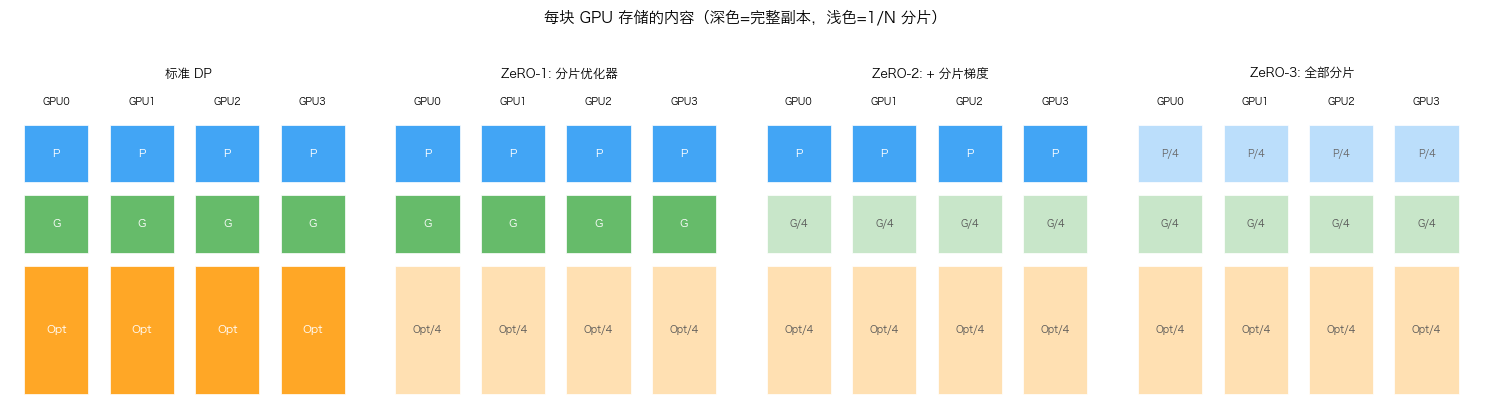

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ["标准 DP", "ZeRO-1: 分片优化器", "ZeRO-2: + 分片梯度", "ZeRO-3: 全部分片"]

for ax_idx, (ax, title) in enumerate(zip(axes, titles)):
    ax.set_xlim(0, 5); ax.set_ylim(0, 5); ax.axis("off")
    ax.set_title(title, fontsize=9, fontweight="bold")

    for gpu in range(4):
        x = 0.2 + gpu * 1.2
        ax.text(x + 0.45, 4.7, f"GPU{gpu}", ha="center", fontsize=7, fontweight="bold")

        # 参数
        if ax_idx < 3:
            ax.add_patch(patches.Rectangle((x, 3.5), 0.9, 0.9,
                facecolor="#42a5f5", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 3.95, "P", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        else:
            ax.add_patch(patches.Rectangle((x, 3.5), 0.9, 0.9,
                facecolor="#bbdefb", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 3.95, "P/4", ha="center", va="center", fontsize=7, color="#666", fontweight="bold")

        # 梯度
        if ax_idx < 2:
            ax.add_patch(patches.Rectangle((x, 2.4), 0.9, 0.9,
                facecolor="#66bb6a", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 2.85, "G", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        else:
            ax.add_patch(patches.Rectangle((x, 2.4), 0.9, 0.9,
                facecolor="#c8e6c9", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 2.85, "G/4", ha="center", va="center", fontsize=7, color="#555", fontweight="bold")

        # 优化器状态
        if ax_idx == 0:
            ax.add_patch(patches.Rectangle((x, 0.2), 0.9, 2.0,
                facecolor="#ffa726", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 1.2, "Opt", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        else:
            ax.add_patch(patches.Rectangle((x, 0.2), 0.9, 2.0,
                facecolor="#ffe0b2", edgecolor="white", lw=0.5))
            ax.text(x + 0.45, 1.2, "Opt/4", ha="center", va="center", fontsize=7, color="#555", fontweight="bold")

fig.suptitle("每块 GPU 存储的内容（深色=完整副本，浅色=1/N 分片）", fontsize=11, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 6. FSDP — PyTorch 原生 ZeRO 阶段 3

**全分片数据并行（FSDP）**是 PyTorch 内置的 ZeRO Stage 3 实现。

FSDP 中参数的生命周期：

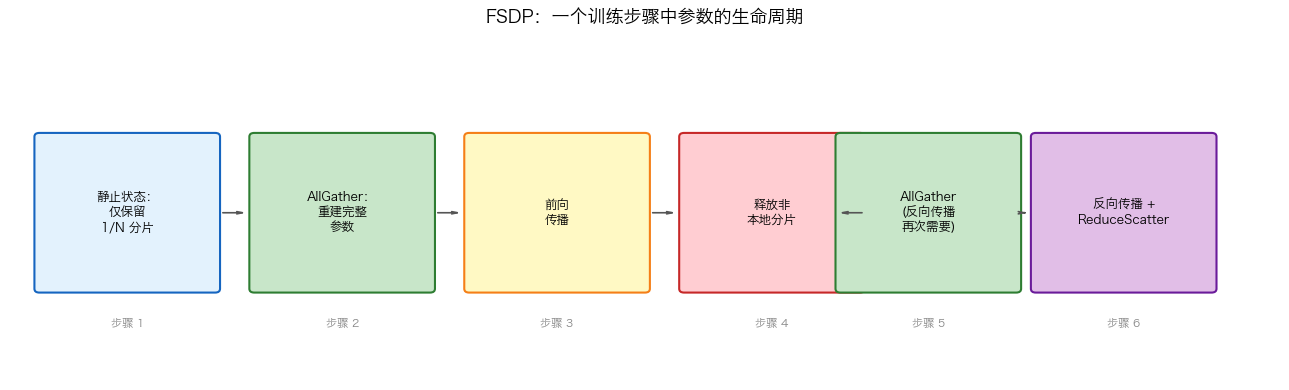

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.5)
ax.axis("off")
ax.set_title("FSDP：一个训练步骤中参数的生命周期", fontsize=13, fontweight="bold", pad=10)

steps = [
    (0.3,  "静止状态：\n仅保留\n1/N 分片", "#e3f2fd", "#1565c0"),
    (2.5,  "AllGather：\n重建完整\n参数", "#c8e6c9", "#2e7d32"),
    (4.7,  "前向\n传播", "#fff9c4", "#f57f17"),
    (6.9,  "释放非\n本地分片", "#ffcdd2", "#c62828"),
    (8.5,  "AllGather\n(反向传播\n再次需要)", "#c8e6c9", "#2e7d32"),
    (10.5, "反向传播 +\nReduceScatter", "#e1bee7", "#6a1b9a"),
]

for i, (x, label, fc, ec) in enumerate(steps):
    w = 1.8
    ax.add_patch(patches.FancyBboxPatch((x, 1.2), w, 2.0, boxstyle="round,pad=0.05",
        facecolor=fc, edgecolor=ec, lw=1.5))
    ax.text(x + w/2, 2.2, label, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(x + w/2, 0.7, f"步骤 {i+1}", ha="center", fontsize=8, color="#888")
    if i < len(steps) - 1:
        nx = steps[i+1][0]
        ax.annotate("", xy=(nx - 0.05, 2.2), xytext=(x + w + 0.05, 2.2),
            arrowprops=dict(arrowstyle="->,head_width=0.08", color="#555", lw=1.2))

plt.tight_layout()
plt.show()

In [16]:
info_box(
    "<b>AllGather</b> — 每块 GPU 将自己的分片发送给所有其他 GPU，所有人都能重建完整张量。"
    "就像每人分享自己的拼图碎片，所有人都能看到完整图片。<br><br>"
    "<b>ReduceScatter</b> — 相反的操作：先汇总所有人的数据（求和），再让每块 GPU 只取其中 1/N 的结果。"
    "把归约和分发合成一步。",
    title="新术语：AllGather 与 ReduceScatter"
)

### 通信开销对比：DDP vs FSDP

FSDP 以**更多通信**换取**更少显存**：

In [17]:
comparison_table(
    ["", "DDP", "FSDP (ZeRO-3)"],
    [
        ["每 GPU 显存", "完整模型 + 梯度 + 优化器", "所有内容的 1/N"],
        ["每步通信量", "2 × 模型大小<br>(1 次 AllReduce = ReduceScatter + AllGather)",
         "3 × 模型大小<br>(AllGather×2 + ReduceScatter)"],
        ["相对 DDP 通信开销", "1×", "1.5×"],
        ["适用场景", "模型能放入单卡显存", "模型放不进单卡显存"],
    ],
    title="DDP vs FSDP 权衡"
)

,DDP,FSDP (ZeRO-3)
每 GPU 显存,完整模型 + 梯度 + 优化器,所有内容的 1/N
每步通信量,2 × 模型大小(1 次 AllReduce = ReduceScatter + AllGather),3 × 模型大小(AllGather×2 + ReduceScatter)
相对 DDP 通信开销,1×,1.5×
适用场景,模型能放入单卡显存,模型放不进单卡显存


## 7. 数据并行在大语言模型中的应用

实际上，DP 是**所有**大模型训练的基石。看看业界怎么用：

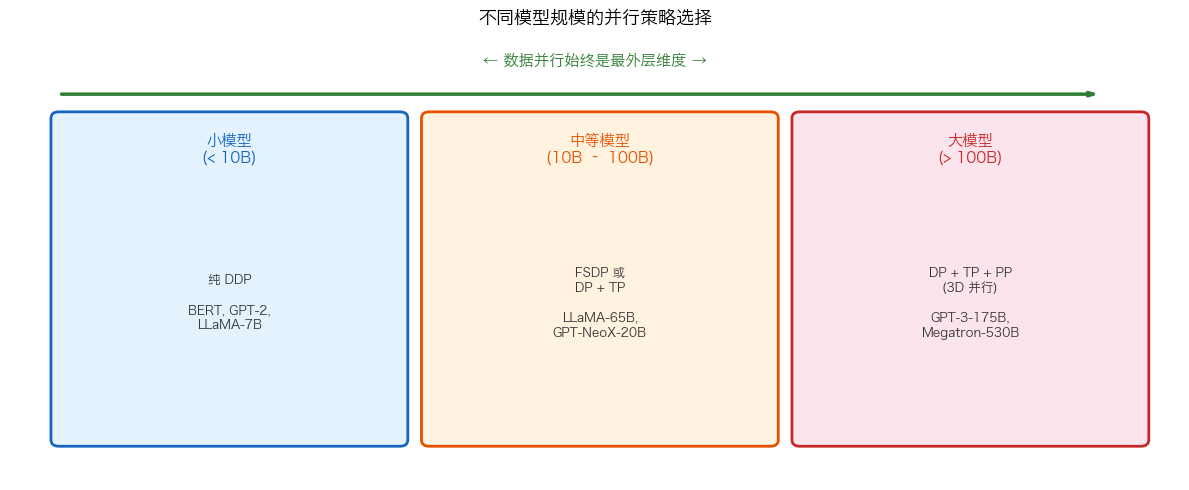

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("不同模型规模的并行策略选择", fontsize=13, fontweight="bold", pad=10)

regions = [
    (0.5, 0.5, 3.5, 4.0, "#e3f2fd", "小模型\n(< 10B)",
     "纯 DDP\n\nBERT, GPT-2,\nLLaMA-7B", "#1565c0"),
    (4.3, 0.5, 3.5, 4.0, "#fff3e0", "中等模型\n(10B – 100B)",
     "FSDP 或\nDP + TP\n\nLLaMA-65B,\nGPT-NeoX-20B", "#e65100"),
    (8.1, 0.5, 3.5, 4.0, "#fce4ec", "大模型\n(> 100B)",
     "DP + TP + PP\n(3D 并行)\n\nGPT-3-175B,\nMegatron-530B", "#c62828"),
]
for x, y, w, h, fc, title, desc, ec in regions:
    ax.add_patch(patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
        facecolor=fc, edgecolor=ec, lw=2))
    ax.text(x + w/2, y + h - 0.4, title, ha="center", va="center", fontsize=11, fontweight="bold", color=ec)
    ax.text(x + w/2, y + h/2 - 0.3, desc, ha="center", va="center", fontsize=9, color="#333")

ax.annotate("", xy=(11.2, 4.8), xytext=(0.5, 4.8),
    arrowprops=dict(arrowstyle="->,head_width=0.12", color="#2e7d32", lw=2.5))
ax.text(6, 5.15, "← 数据并行始终是最外层维度 →",
    ha="center", fontsize=11, fontweight="bold", color="#2e7d32")

plt.tight_layout()
plt.show()

In [19]:
info_box(
    "在多维并行（如 TP × PP × DP）中，数据并行始终是<b>最外层</b>，因为：<br>"
    "1. 每步只需通信一次（梯度同步）<br>"
    "2. 线性扩展——GPU 翻倍 ≈ 吞吐量翻倍<br>"
    "3. 没有流水线气泡或激活值显存额外开销",
    title="为什么 DP 总是在最外层"
)

### 扩展效率

随着 GPU 数量增加，通信开销也在增长。让我们可视化：

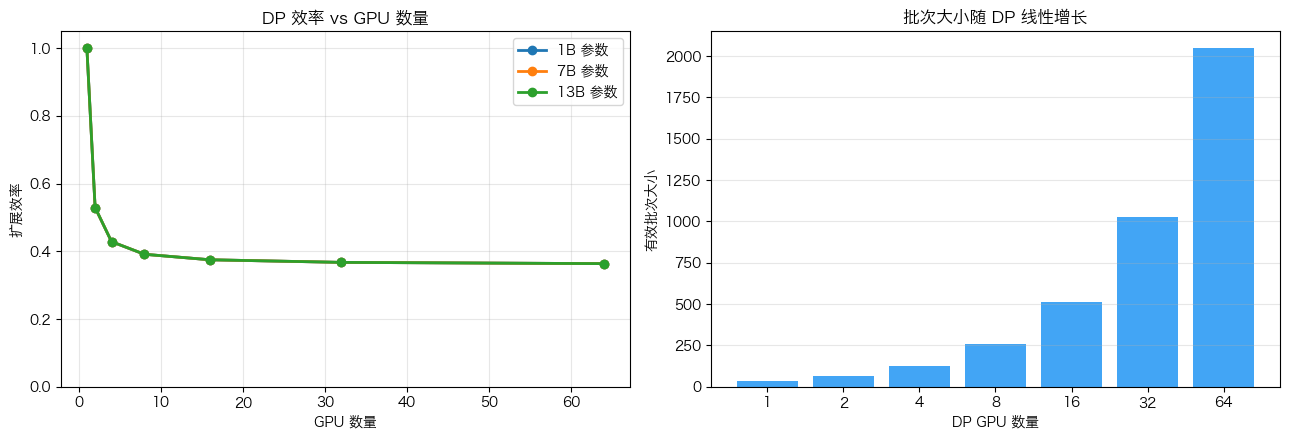

In [20]:
model_sizes_B = [1, 7, 13]
gpu_counts = [1, 2, 4, 8, 16, 32, 64]
bandwidth_gbps = 300

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for model_B in model_sizes_B:
    compute_ms = model_B * 15
    effs = []
    for n in gpu_counts:
        if n == 1:
            effs.append(1.0)
            continue
        data_gb = model_B * 1e9 * 4 / 1e9
        comm_ms = 2 * (n-1)/n * data_gb / bandwidth_gbps * 1000
        eff = compute_ms / (compute_ms + comm_ms)
        effs.append(eff)
    ax1.plot(gpu_counts, effs, "o-", lw=2, label=f"{model_B}B 参数")

ax1.set_xlabel("GPU 数量", fontsize=10)
ax1.set_ylabel("扩展效率", fontsize=10)
ax1.set_title("DP 效率 vs GPU 数量", fontweight="bold")
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 1.05)

dp_sizes = [1, 2, 4, 8, 16, 32, 64]
local_batch = 32
ax2.bar(range(len(dp_sizes)), [local_batch * n for n in dp_sizes], color="#42a5f5")
ax2.set_xticks(range(len(dp_sizes))); ax2.set_xticklabels(dp_sizes)
ax2.set_xlabel("DP GPU 数量", fontsize=10)
ax2.set_ylabel("有效批次大小", fontsize=10)
ax2.set_title("批次大小随 DP 线性增长", fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 8. 实战：真实 DDP 训练脚本

以下是一个**完整可运行**的 DDP 训练脚本。保存后在多卡机器上运行：

```bash
# 在多卡 GPU 机器上:
torchrun --nproc_per_node=4 ddp_train.py
```

In [21]:
gpu_required_banner()

In [22]:
# [GPU-REQUIRED]
# 完整 DDP 训练脚本 — 保存为 ddp_train.py

DDP_SCRIPT = '''\
import os
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, TensorDataset, DistributedSampler

def main():
    # 1. 初始化分布式 — GPU 使用 NCCL 后端
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()          # 当前 GPU 的 ID (0, 1, 2, ...)
    world_size = dist.get_world_size()  # GPU 总数
    device = torch.device(f"cuda:{rank}")
    torch.cuda.set_device(device)

    # 2. 创建模型并放到当前 GPU 上
    model = nn.Sequential(
        nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 10)
    ).to(device)

    # 3. 用 DDP 包装 — 梯度同步将自动完成
    model = DDP(model, device_ids=[rank])

    # 4. 数据集 + DistributedSampler（自动在 GPU 间分割数据）
    X = torch.randn(1000, 128)
    y = torch.randint(0, 10, (1000,))
    sampler = DistributedSampler(TensorDataset(X, y), num_replicas=world_size, rank=rank)
    loader = DataLoader(TensorDataset(X, y), batch_size=32, sampler=sampler)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    # 5. 训练
    for epoch in range(5):
        sampler.set_epoch(epoch)   # 每个 epoch 不同的 shuffle
        total_loss = 0.0
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(batch_X), batch_y)
            loss.backward()        # DDP 在这里自动同步梯度！
            optimizer.step()
            total_loss += loss.item()
        if rank == 0:
            print(f"Epoch {epoch+1}: loss = {total_loss/len(loader):.4f}")

    dist.destroy_process_group()

if __name__ == "__main__":
    main()
'''

print(DDP_SCRIPT)
print("# 运行方式: torchrun --nproc_per_node=4 ddp_train.py")

import os
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, TensorDataset, DistributedSampler

def main():
    # 1. 初始化分布式 — GPU 使用 NCCL 后端
    dist.init_process_group(backend="nccl")
    rank = dist.get_rank()          # 当前 GPU 的 ID (0, 1, 2, ...)
    world_size = dist.get_world_size()  # GPU 总数
    device = torch.device(f"cuda:{rank}")
    torch.cuda.set_device(device)

    # 2. 创建模型并放到当前 GPU 上
    model = nn.Sequential(
        nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 10)
    ).to(device)

    # 3. 用 DDP 包装 — 梯度同步将自动完成
    model = DDP(model, device_ids=[rank])

    # 4. 数据集 + DistributedSampler（自动在 GPU 间分割数据）
    X = torch.randn(1000, 128)
    y = torch.randint(0, 10, (1000,))
    sampler = DistributedSampler(TensorDataset(X, y), num_replicas=world_size, rank=rank)
    loader = DataLoader(TensorDataset(X, y), batch_size=32, sampler=sampler)

    optimizer = t

## 9. Megatron-LM 参考

在 Megatron 的 3D 并行框架中，DP 与 TP、PP 结合使用。关键实现细节：

In [22]:
code_reference(
    code="""# Megatron-LM 将 GPU 组织为进程组。
# 数据并行组 = 拥有相同 TP rank + 相同 PP stage 的 GPU，
# 但处理不同的数据分片。
#
# 示例：16 块 GPU, TP=4, PP=1, DP=4
# TP 组: [0,1,2,3], [4,5,6,7], [8,9,10,11], [12,13,14,15]
# DP 组: [0,4,8,12], [1,5,9,13], [2,6,10,14], [3,7,11,15]
#
# 每个 DP 组独立执行 AllReduce。
# megatron/core/parallel_state.py
def initialize_model_parallel(
    tensor_model_parallel_size,
    pipeline_model_parallel_size, ...
):
    # 从 TP/PP 分配后剩余的 GPU 中构建 DP 组
    ...""",
    source="Megatron-LM",
    filepath="megatron/core/parallel_state.py"
)

In [23]:
code_reference(
    code="""# Megatron 使用自己的 DDP 包装器（不是 PyTorch 默认的）
# 因为模型已经被 TP/PP 切分了。
#
# megatron/core/distributed/distributed_data_parallel.py
class DistributedDataParallel(MegatronModule):
    '''在数据并行进程组内执行梯度 AllReduce。

    与 torch DDP 的关键区别：
    - 仅在 DP 组内 AllReduce（不是所有 GPU）
    - 适用于已被 TP 和 PP 切分的模型
    - 支持跨微批次的梯度累积
    '''""",
    source="Megatron-LM",
    filepath="megatron/core/distributed/distributed_data_parallel.py"
)

## 10. 总结

本笔记本涵盖的内容：

In [24]:
comparison_table(
    ["技术", "核心思想", "显存", "通信量", "适用场景"],
    [
        ["朴素 DP", "复制模型，分割数据，平均梯度",
         "每 GPU 完整副本", "朴素聚合 → 瓶颈", "仅供理解（实际不用）"],
        ["DDP", "AllReduce + 梯度分桶 + 重叠",
         "每 GPU 完整副本", "2× 模型大小（高效）", "模型放得进单卡"],
        ["ZeRO-1", "分片优化器状态",
         "优化器显存减少约 4 倍", "与 DDP 相同", "优化器是瓶颈"],
        ["ZeRO-2", "ZeRO-1 + 分片梯度",
         "更少", "与 DDP 相同", "需要更多显存节省"],
        ["ZeRO-3 / FSDP", "全部分片（参数+梯度+优化器）",
         "所有内容的 1/N", "3× 模型大小（1.5× DDP）", "模型放不进单卡"],
    ],
    title="数据并行家族 — 对比表"
)

技术,核心思想,显存,通信量,适用场景
朴素 DP,复制模型，分割数据，平均梯度,每 GPU 完整副本,朴素聚合 → 瓶颈,仅供理解（实际不用）
DDP,AllReduce + 梯度分桶 + 重叠,每 GPU 完整副本,2× 模型大小（高效）,模型放得进单卡
ZeRO-1,分片优化器状态,优化器显存减少约 4 倍,与 DDP 相同,优化器是瓶颈
ZeRO-2,ZeRO-1 + 分片梯度,更少,与 DDP 相同,需要更多显存节省
ZeRO-3 / FSDP,全部分片（参数+梯度+优化器）,所有内容的 1/N,3× 模型大小（1.5× DDP）,模型放不进单卡


### 核心公式

| 公式 | 含义 |
|------|------|
| $g_{\text{avg}} = \frac{1}{N} \sum_{i=1}^{N} g_i$ | N 块 GPU 上的梯度平均 |
| $B_{\text{effective}} = b_{\text{local}} \times N_{\text{DP}} \times \text{grad\_accum}$ | 有效批次大小 |
| DDP 通信量: $2 \times |\theta|$ | AllReduce = ReduceScatter + AllGather |
| FSDP 通信量: $3 \times |\theta|$ | 2× AllGather + 1× ReduceScatter |

### 下一个笔记本

**[02 — 张量并行](02-tensor-parallelism.ipynb)**：将单个*层*切分到多块 GPU（与 DP 互补）。

### 延伸阅读

- [ZeRO: Memory Optimizations Toward Training Trillion Parameter Models](https://arxiv.org/abs/1910.02054)
- [PyTorch DDP 教程](https://pytorch.org/tutorials/beginner/dist_overview.html)
- [PyTorch FSDP 教程](https://pytorch.org/tutorials/intermediate/FSDP_tutorial.html)
- [Efficient Large-Scale Language Model Training on GPU Clusters](https://arxiv.org/abs/2104.04473)